# Notebook 3: Comparing Ordering Policies

**Goal:** Show how different ordering policies affect the bullwhip effect and
total cost, and demonstrate how to implement custom policies.

We will:
1. Compare Order-Up-To (OUT) vs. fixed-order-quantity
2. Implement a smoothing policy that dampens order variability
3. Visualize the impact on orders, inventory, and costs
4. Run a head-to-head comparison across all metrics

In [1]:
# --- Colab / Environment Setup ---
# Run this cell first if using Google Colab or a fresh environment.
import importlib, sys

if "google.colab" in sys.modules:
    print("Running on Google Colab -- installing deepbullwhip...")
    get_ipython().system('pip install -q deepbullwhip')
elif importlib.util.find_spec("deepbullwhip") is None:
    print("deepbullwhip not found -- installing from local source...")
    get_ipython().system('pip install -q -e ..')
else:
    print(f"deepbullwhip ready (v{__import__('deepbullwhip').__version__})")

deepbullwhip ready (v0.3.0)


In [2]:
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline
%config InlineBackend.figure_format = 'retina'

SEED = 966  # Saudi country code

In [3]:
from deepbullwhip import (
    SemiconductorDemandGenerator, SerialSupplyChain,
    SupplyChainEchelon, NewsvendorCost, OrderUpToPolicy,
    default_semiconductor_config,
)
from deepbullwhip.policy.base import OrderingPolicy

gen = SemiconductorDemandGenerator()
demand = gen.generate(T=156, seed=SEED)
fm = np.full_like(demand, demand.mean())
fs = np.full_like(demand, demand.std())

## 1. Baseline: Order-Up-To (OUT) Policy

This is the default policy. Each period:

$$q = \max\bigl(0,\; (L{+}1)\hat\mu + z_\alpha \hat\sigma\sqrt{L{+}1} - \text{IP}\bigr)$$

In [4]:
chain_out = SerialSupplyChain()
result_out = chain_out.simulate(demand, fm, fs)

print("OUT Policy:")
print(f"  Cumulative BW: {result_out.cumulative_bullwhip:.2f}")
print(f"  Total cost:    {result_out.total_cost:,.0f}")

OUT Policy:
  Cumulative BW: 1040.42
  Total cost:    4,728


## 2. Policy A: Fixed Order Quantity

The simplest possible policy — order the same amount every period.
No bullwhip by design, but poor responsiveness.

In [5]:
class FixedOrderPolicy(OrderingPolicy):
    """Order a fixed quantity every period, regardless of inventory."""
    def __init__(self, quantity: float):
        self.quantity = quantity

    def compute_order(self, inventory_position, forecast_mean, forecast_std):
        return self.quantity


def build_chain(policy_factory):
    """Build a 4-echelon chain using a given policy factory."""
    echelons = []
    for cfg in default_semiconductor_config():
        total_h = cfg.holding_cost + cfg.depreciation_rate
        echelons.append(SupplyChainEchelon(
            name=cfg.name, lead_time=cfg.lead_time,
            policy=policy_factory(cfg),
            cost_fn=NewsvendorCost(total_h, cfg.backorder_cost),
            initial_inventory=cfg.initial_inventory,
        ))
    return SerialSupplyChain(echelons=echelons)


chain_fixed = build_chain(lambda cfg: FixedOrderPolicy(demand.mean()))
result_fixed = chain_fixed.simulate(demand, fm, fs)

print("Fixed Order Policy:")
print(f"  Cumulative BW: {result_fixed.cumulative_bullwhip:.2f}")
print(f"  Total cost:    {result_fixed.total_cost:,.0f}")

Fixed Order Policy:
  Cumulative BW: 0.00
  Total cost:    11,070


## 3. Policy B: Smoothing Policy

A compromise: use OUT but apply exponential smoothing to dampen order swings.

$$q_t = \alpha \cdot q_t^{\text{OUT}} + (1 - \alpha) \cdot q_{t-1}$$

Lower $\alpha$ = more smoothing = less bullwhip, but slower response.

In [6]:
class SmoothedOUTPolicy(OrderingPolicy):
    """Order-Up-To with exponential smoothing on order quantities."""
    def __init__(self, lead_time: int, service_level: float = 0.95, alpha: float = 0.3):
        self._out = OrderUpToPolicy(lead_time, service_level)
        self.alpha = alpha
        self._prev_order = None

    def compute_order(self, inventory_position, forecast_mean, forecast_std):
        raw = self._out.compute_order(inventory_position, forecast_mean, forecast_std)
        if self._prev_order is None:
            self._prev_order = raw
            return raw
        smoothed = self.alpha * raw + (1 - self.alpha) * self._prev_order
        self._prev_order = smoothed
        return max(0.0, smoothed)


chain_smooth = build_chain(
    lambda cfg: SmoothedOUTPolicy(cfg.lead_time, cfg.service_level, alpha=0.3)
)
result_smooth = chain_smooth.simulate(demand, fm, fs)

print("Smoothed OUT (alpha=0.3):")
print(f"  Cumulative BW: {result_smooth.cumulative_bullwhip:.2f}")
print(f"  Total cost:    {result_smooth.total_cost:,.0f}")

Smoothed OUT (alpha=0.3):
  Cumulative BW: 819.11
  Total cost:    16,003


## 4. Head-to-Head Comparison

### 4.1 Bullwhip Amplification

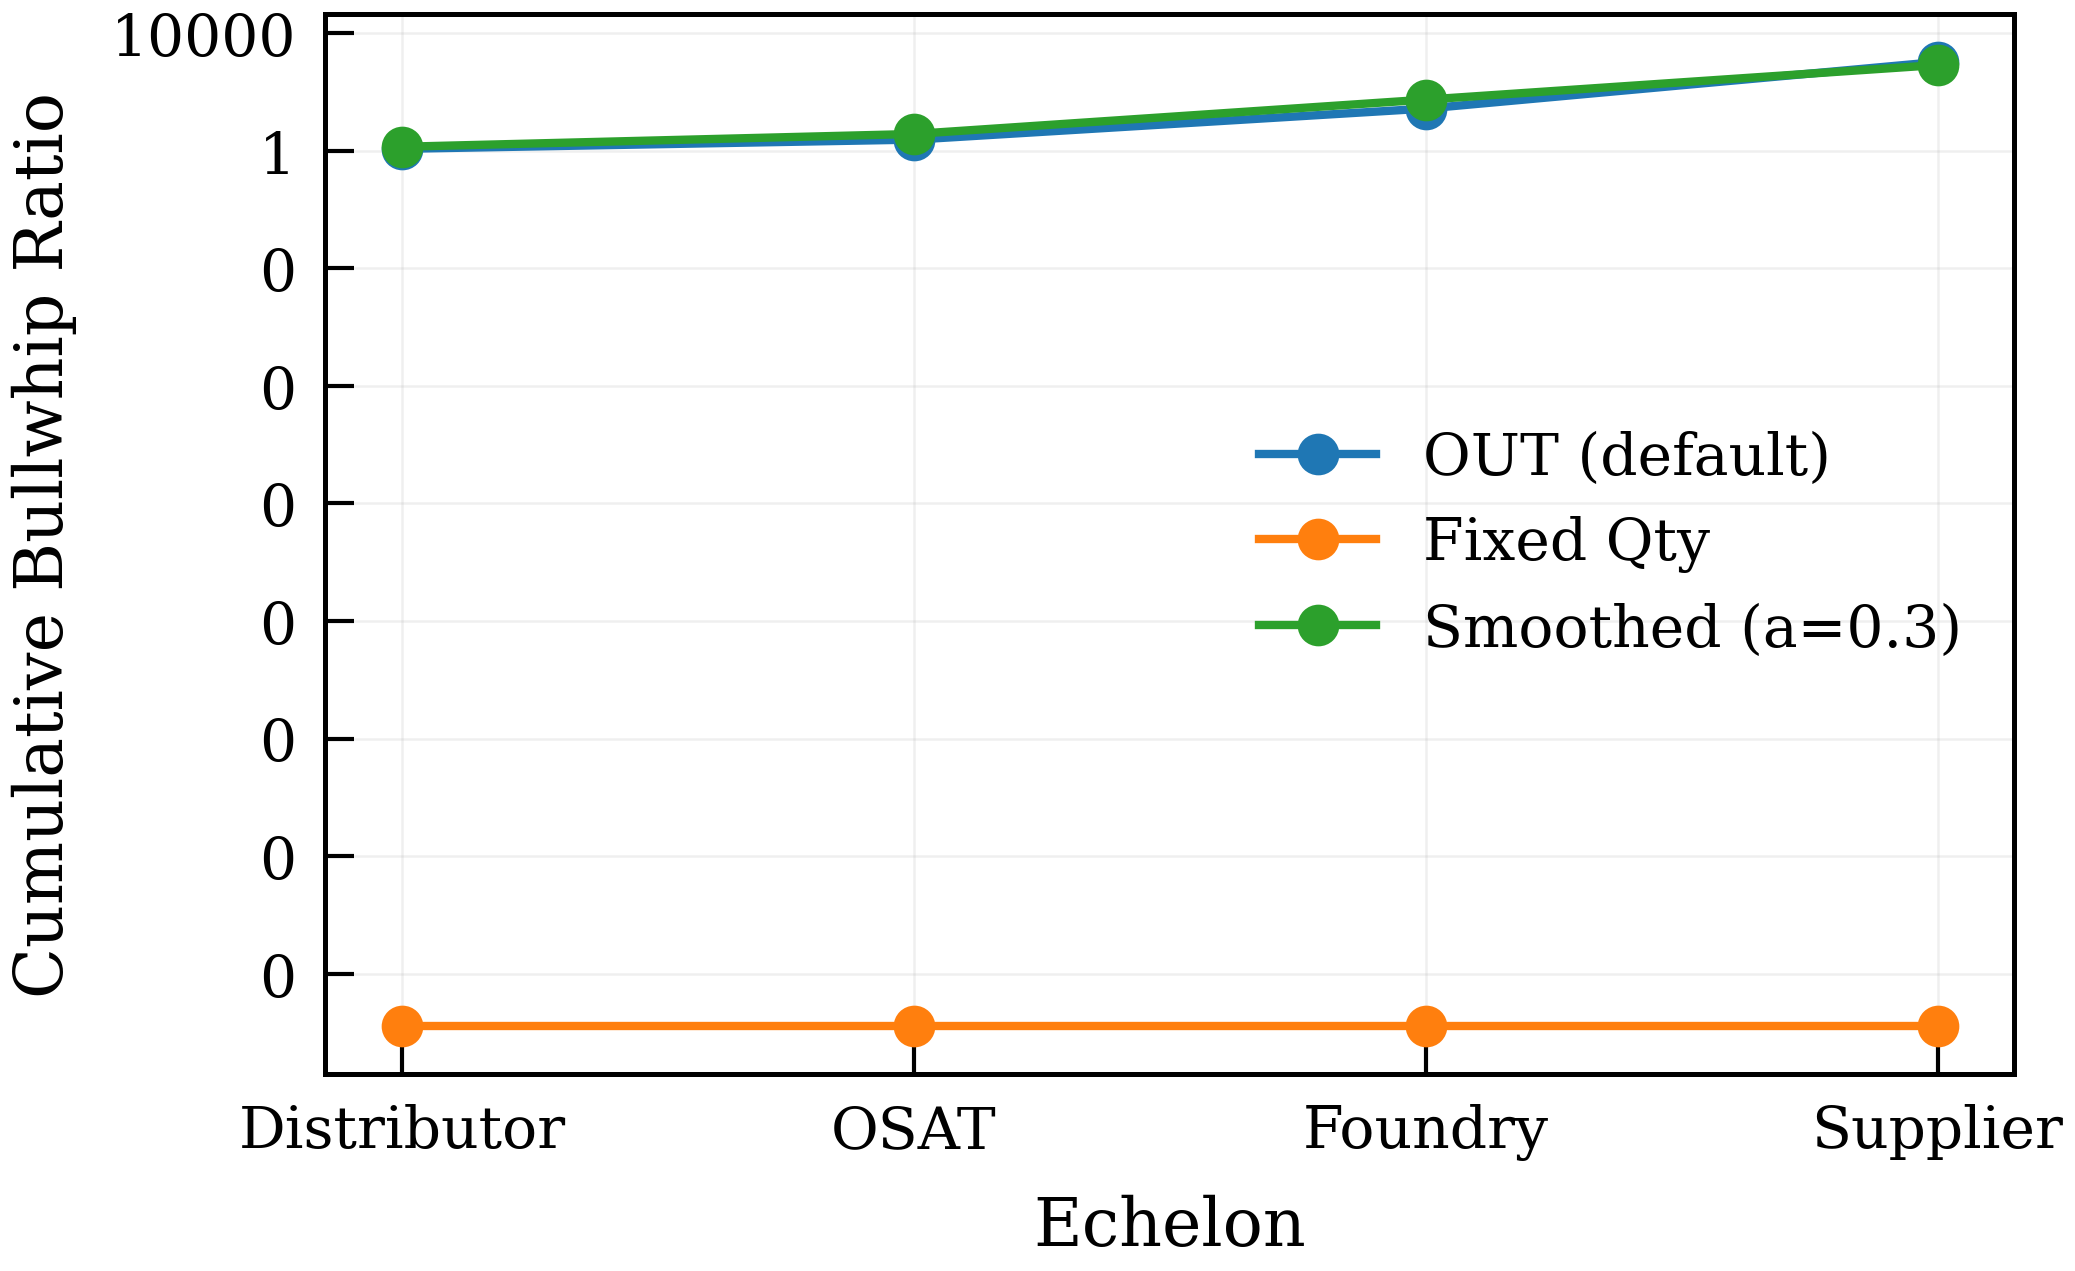

In [7]:
from deepbullwhip.diagnostics.plots import plot_bullwhip_amplification

all_results = {
    "OUT (default)": result_out,
    "Fixed Qty": result_fixed,
    "Smoothed (a=0.3)": result_smooth,
}
labels = [c.name for c in default_semiconductor_config()]

fig = plot_bullwhip_amplification(all_results, echelon_labels=labels)
plt.show()

### 4.2 Order Streams

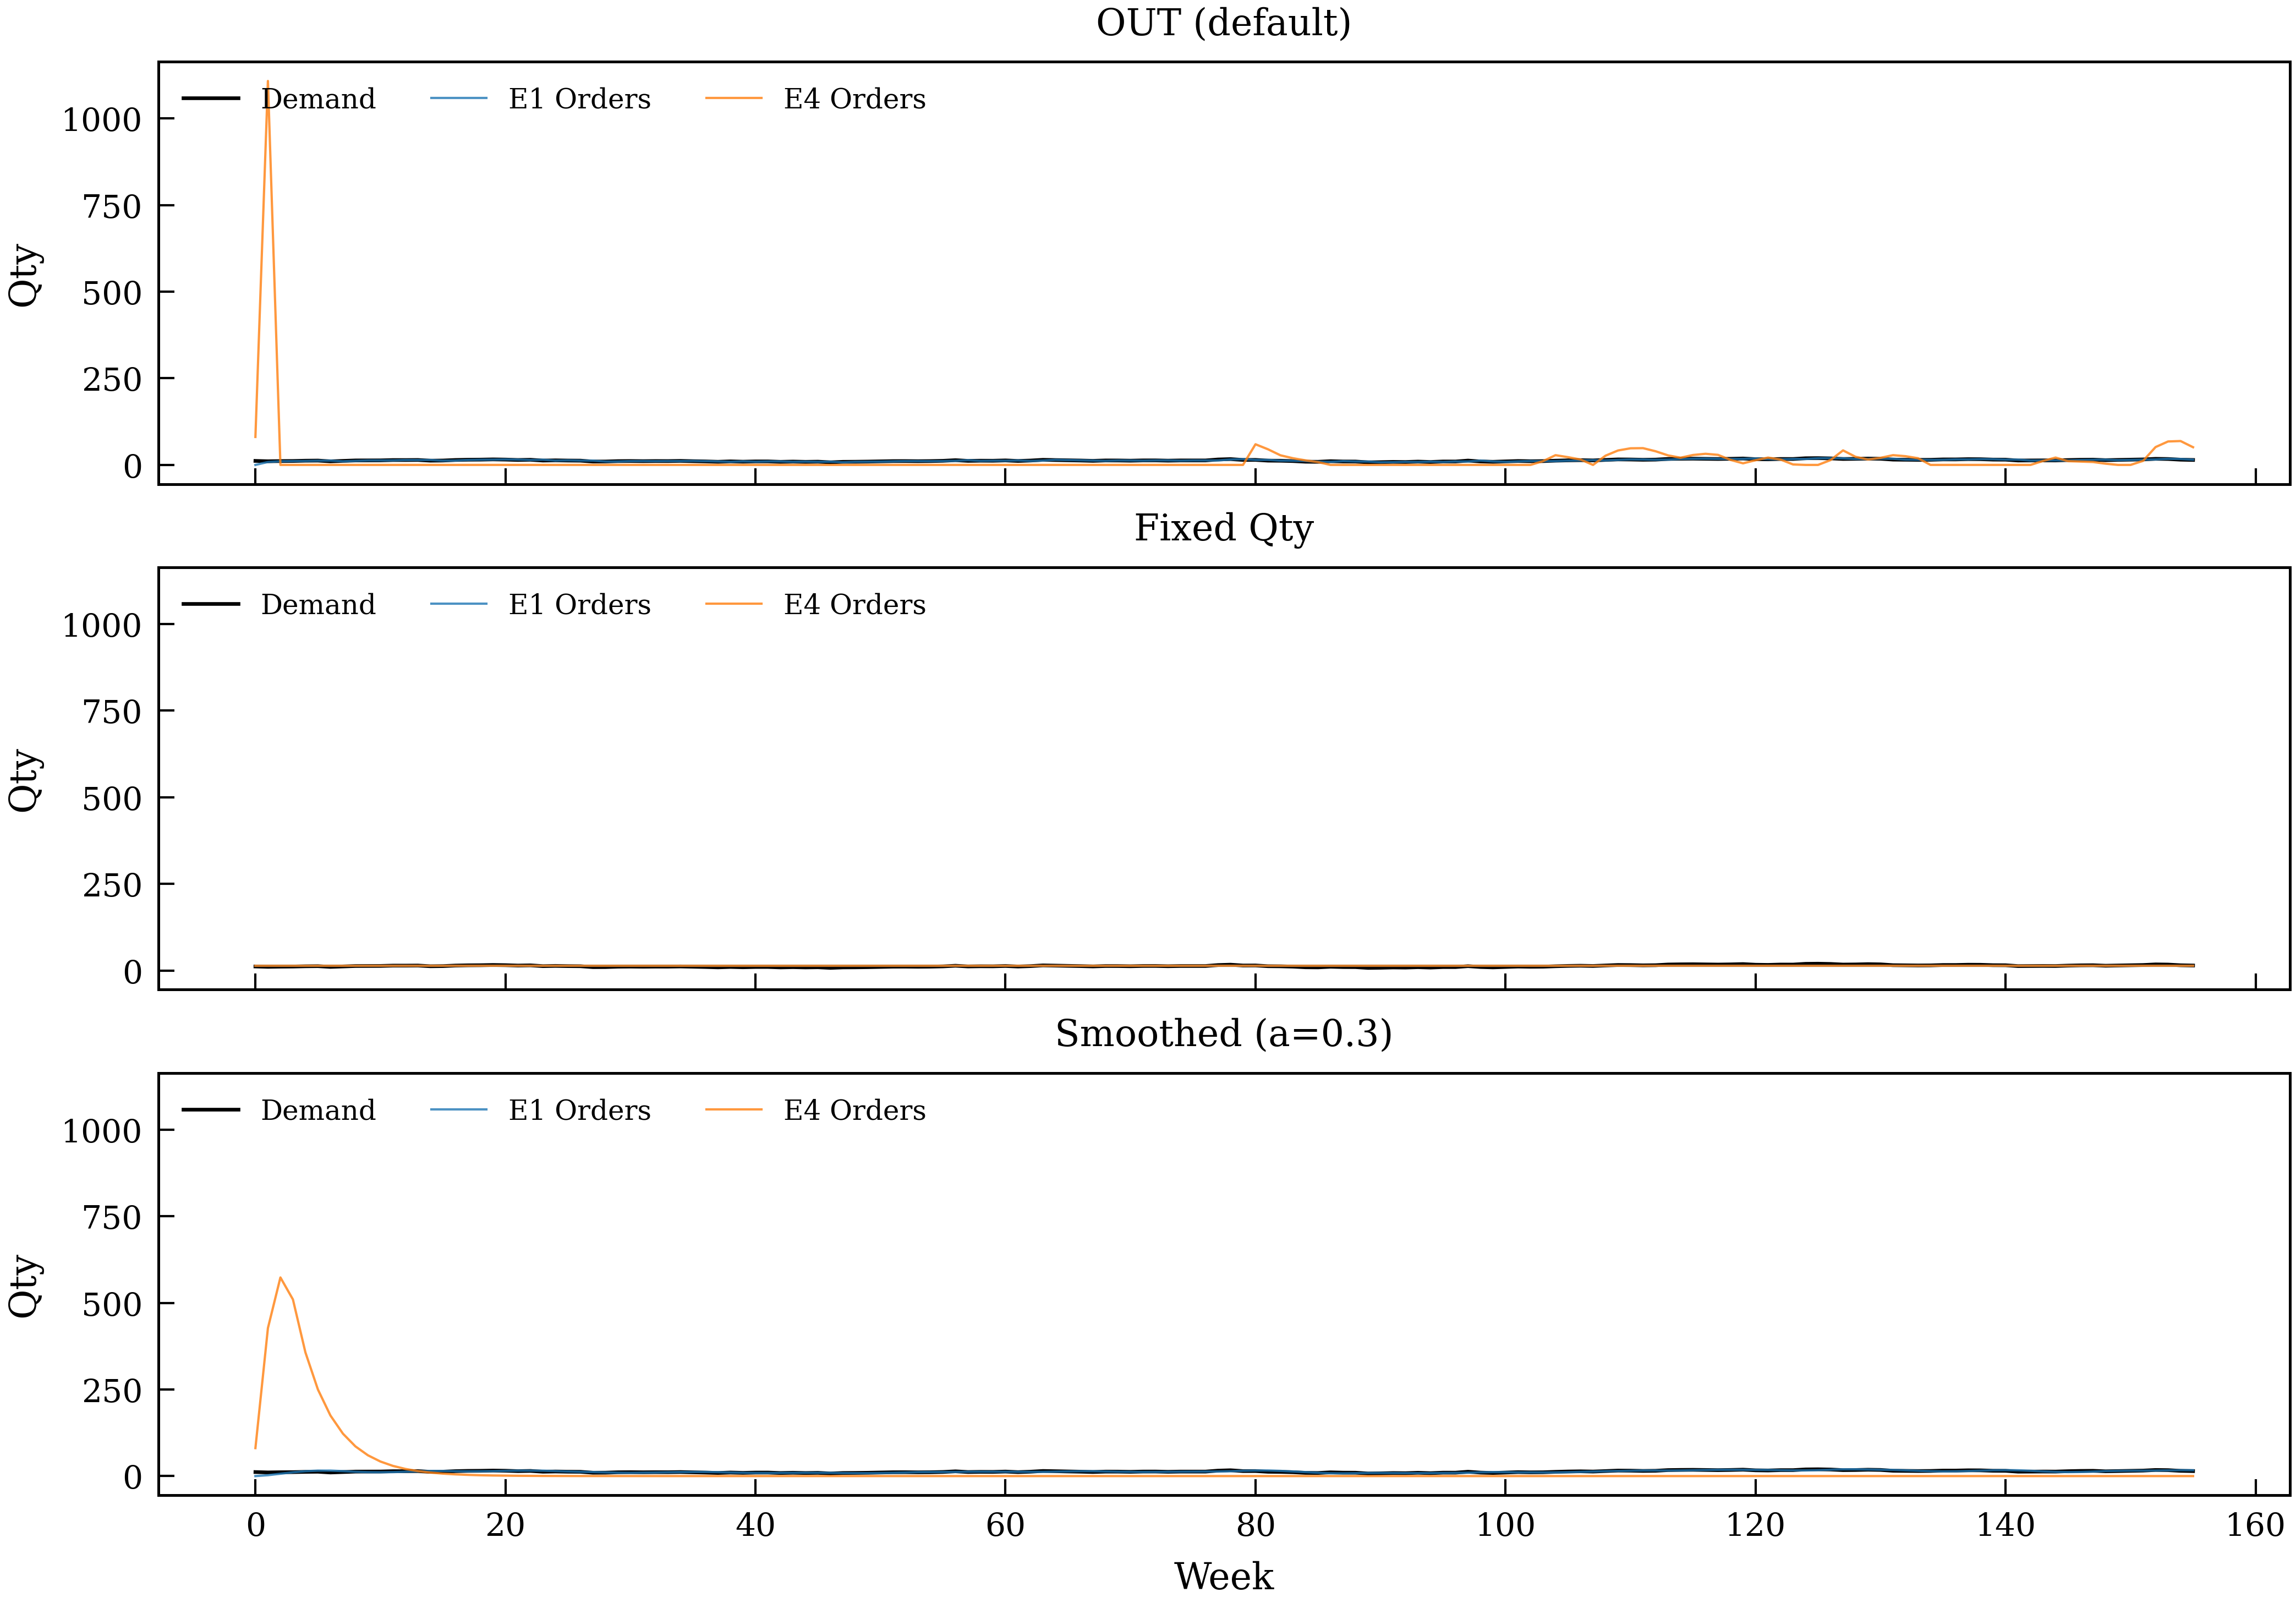

In [8]:
from deepbullwhip.diagnostics.plots import plot_order_streams, _apply_style, DOUBLE_COL, GOLDEN

_apply_style()
fig, axes = plt.subplots(3, 1, figsize=(DOUBLE_COL, DOUBLE_COL * 0.7), sharex=True, sharey=True)

weeks = np.arange(len(demand))
for ax, (name, res) in zip(axes, all_results.items()):
    ax.plot(weeks, demand, color='black', linewidth=0.8, label='Demand')
    # Show E1 and E4 orders
    ax.plot(weeks, res.echelon_results[0].orders, linewidth=0.5, alpha=0.8, label='E1 Orders')
    ax.plot(weeks, res.echelon_results[3].orders, linewidth=0.5, alpha=0.8, label='E4 Orders')
    ax.set_ylabel('Qty')
    ax.set_title(name, fontsize=8)
    ax.legend(loc='upper left', ncol=3, fontsize=6)

axes[-1].set_xlabel('Week')
plt.show()

### 4.3 Cost Comparison

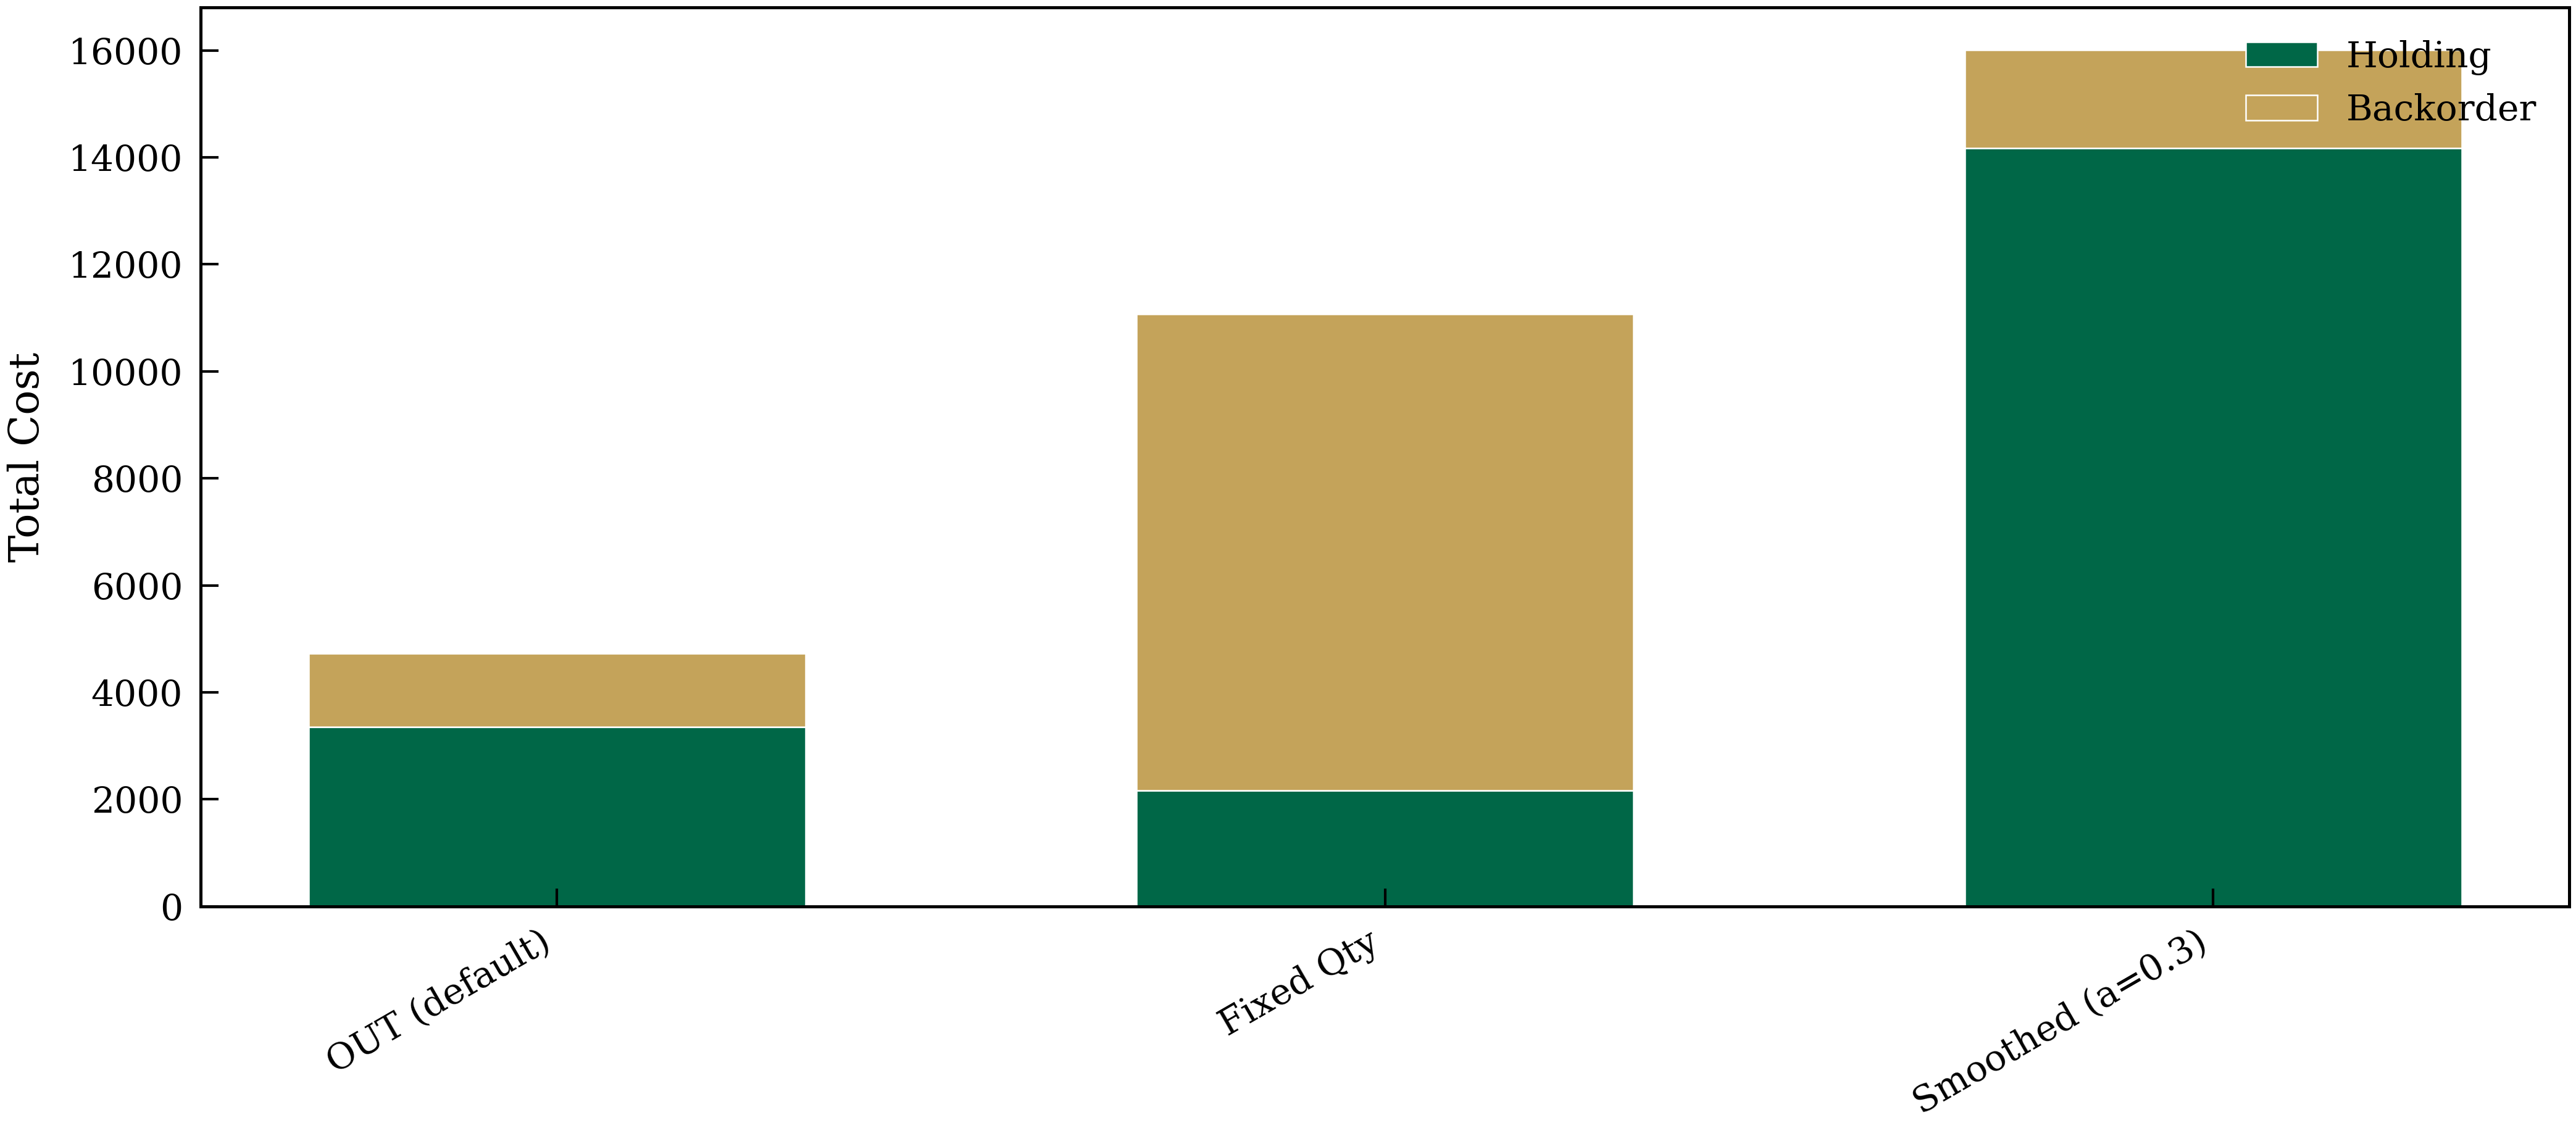

In [9]:
from deepbullwhip.diagnostics.plots import plot_cost_decomposition

fig = plot_cost_decomposition(all_results)
plt.show()

### 4.4 Full Metrics Table

In [10]:
import pandas as pd

rows = []
for name, res in all_results.items():
    bw = [er.bullwhip_ratio for er in res.echelon_results]
    fr = [er.fill_rate for er in res.echelon_results]
    rows.append({
        "Policy": name,
        "BW (E1)": f"{bw[0]:.2f}",
        "BW (E4)": f"{bw[3]:.2f}",
        "BW Cumul.": f"{res.cumulative_bullwhip:.1f}",
        "Avg FR": f"{np.mean(fr):.1%}",
        "Total Cost": f"{res.total_cost:,.0f}",
    })

pd.DataFrame(rows).set_index("Policy")

,BW (E1),BW (E4),BW Cumul.,Avg FR,Total Cost
Policy,,,,,
OUT (default),1.15,38.58,1040.4,74.2%,"4,728"
Fixed Qty,0.00,1.00,0.0,26.4%,"11,070"
Smoothed (a=0.3),1.36,15.02,819.1,76.8%,"16,003"


## 5. Sensitivity to Smoothing Parameter

How does the smoothing parameter $\alpha$ affect the bullwhip-cost tradeoff?

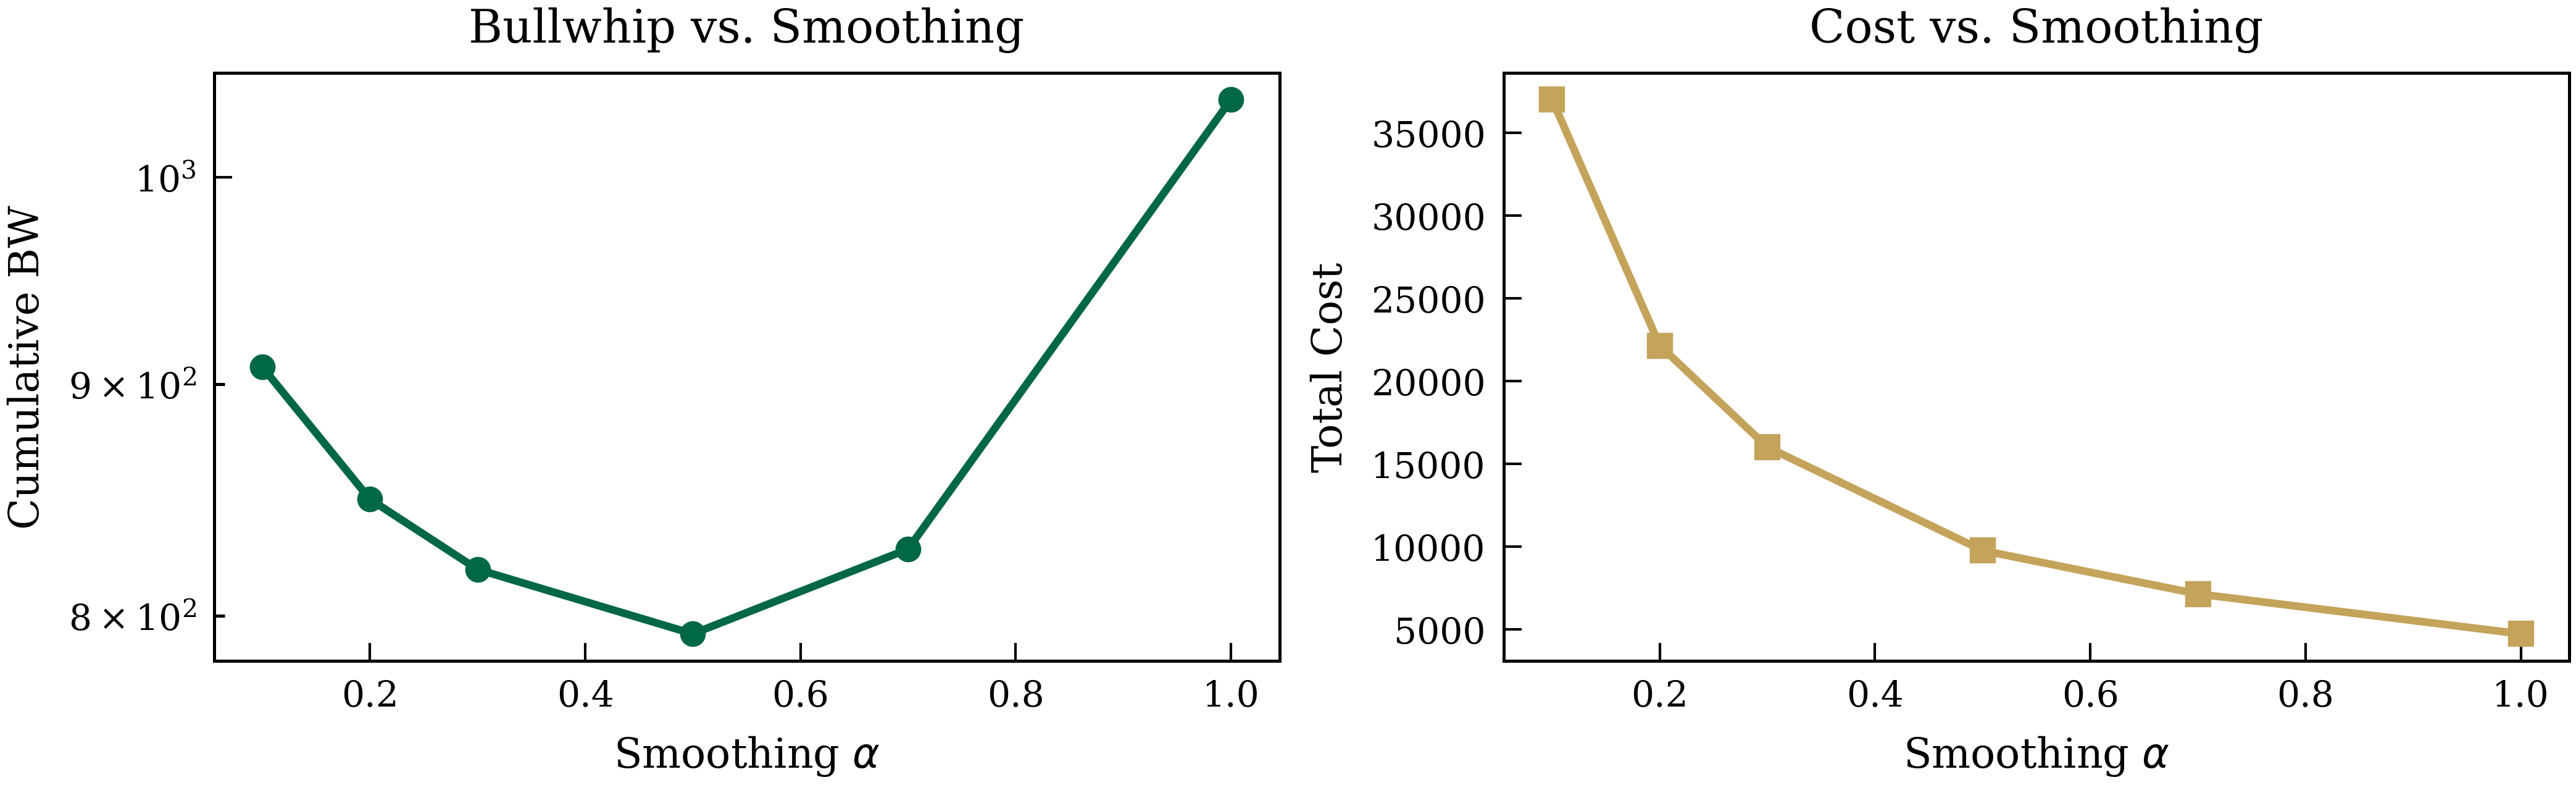

Note: alpha=1.0 is pure OUT (no smoothing)


In [11]:
alphas = [0.1, 0.2, 0.3, 0.5, 0.7, 1.0]
bw_vals = []
cost_vals = []

for a in alphas:
    ch = build_chain(
        lambda cfg, a=a: SmoothedOUTPolicy(cfg.lead_time, cfg.service_level, alpha=a)
    )
    res = ch.simulate(demand, fm, fs)
    bw_vals.append(res.cumulative_bullwhip)
    cost_vals.append(res.total_cost)

_apply_style()
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(DOUBLE_COL, DOUBLE_COL / GOLDEN / 2))

ax1.plot(alphas, bw_vals, 'o-', color='#006747', markersize=4)
ax1.set_xlabel(r'Smoothing $\alpha$')
ax1.set_ylabel('Cumulative BW')
ax1.set_yscale('log')
ax1.set_title('Bullwhip vs. Smoothing')

ax2.plot(alphas, cost_vals, 's-', color='#c4a35a', markersize=4)
ax2.set_xlabel(r'Smoothing $\alpha$')
ax2.set_ylabel('Total Cost')
ax2.set_title('Cost vs. Smoothing')

plt.show()

print(f"Note: alpha=1.0 is pure OUT (no smoothing)")

## 6. Inventory Impact

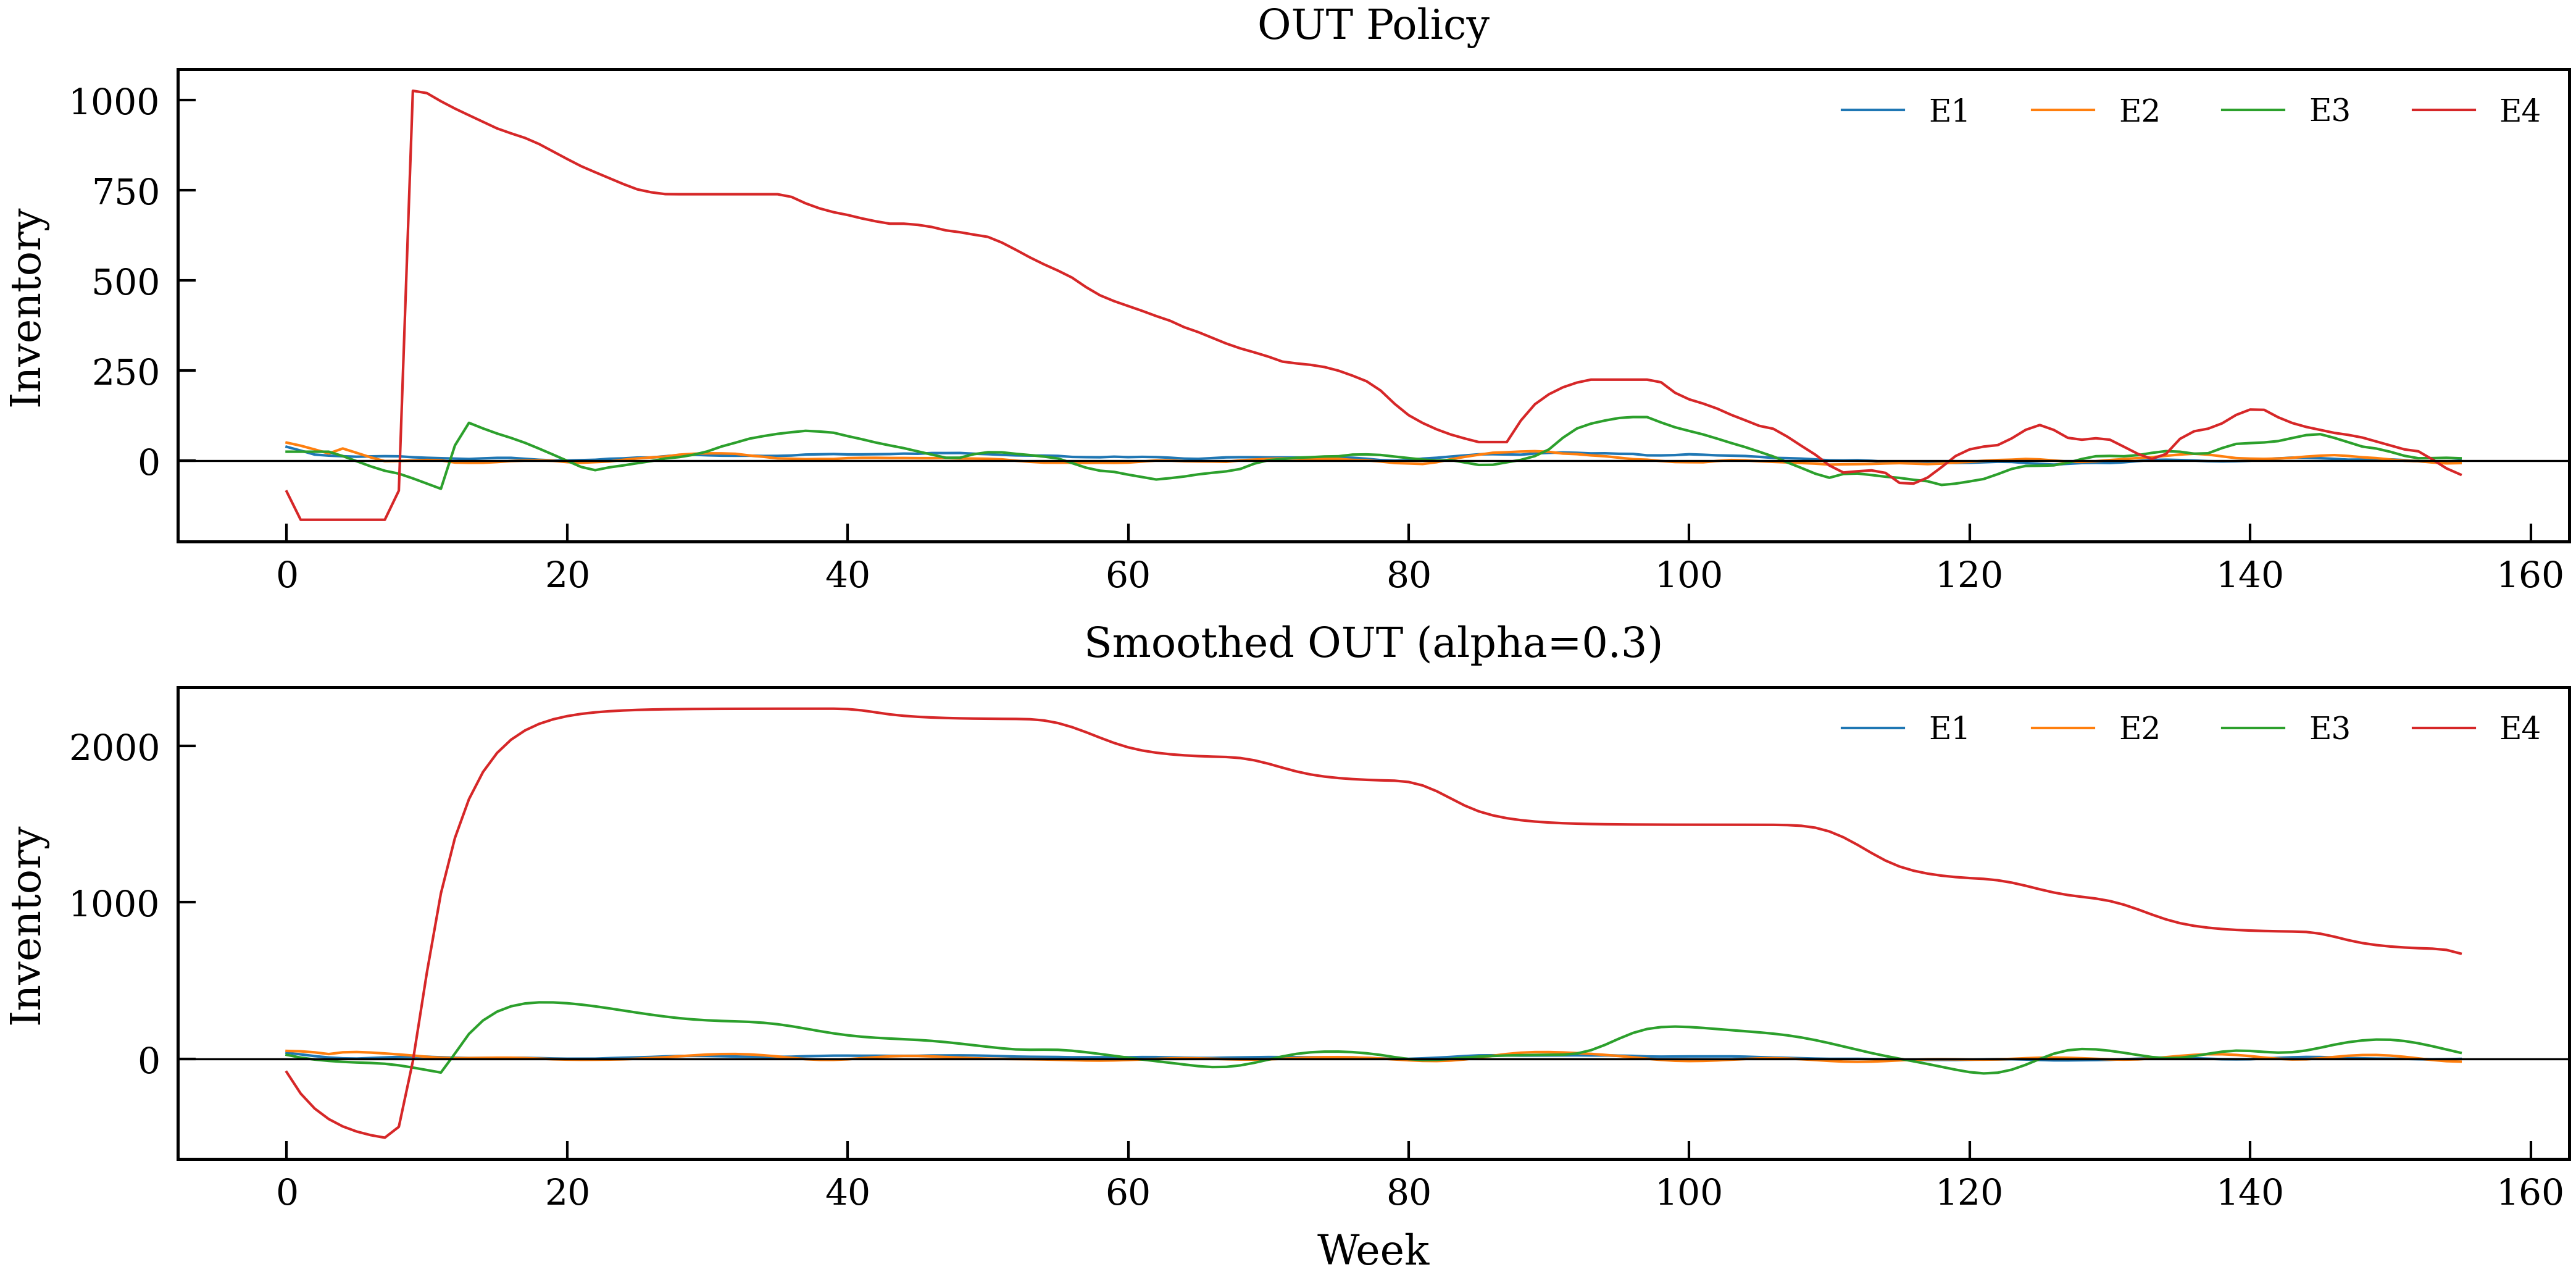

In [12]:
from deepbullwhip.diagnostics.plots import plot_inventory_levels

# Compare inventory profiles for OUT vs smoothed
_apply_style()
fig, axes = plt.subplots(2, 1, figsize=(DOUBLE_COL, DOUBLE_COL * 0.5))

# OUT
weeks = np.arange(len(demand))
for k, er in enumerate(result_out.echelon_results):
    axes[0].plot(weeks, er.inventory_levels, linewidth=0.5, label=f'E{k+1}')
axes[0].axhline(0, color='black', linewidth=0.4)
axes[0].set_ylabel('Inventory')
axes[0].set_title('OUT Policy', fontsize=8)
axes[0].legend(ncol=4, fontsize=6)

# Smoothed
for k, er in enumerate(result_smooth.echelon_results):
    axes[1].plot(weeks, er.inventory_levels, linewidth=0.5, label=f'E{k+1}')
axes[1].axhline(0, color='black', linewidth=0.4)
axes[1].set_ylabel('Inventory')
axes[1].set_xlabel('Week')
axes[1].set_title('Smoothed OUT (alpha=0.3)', fontsize=8)
axes[1].legend(ncol=4, fontsize=6)

plt.show()

## Key Takeaways

1. **Fixed-order eliminates bullwhip** but is impractical — it ignores demand
   signals entirely, leading to persistent stockouts or excess inventory
2. **Smoothing reduces bullwhip** while retaining demand responsiveness —
   a practical middle ground for supply chain managers
3. **The bullwhip-cost tradeoff is non-trivial** — less bullwhip doesn't always
   mean lower cost, because smoothing can delay response to demand changes
4. **Custom policies are easy to implement** — just subclass `OrderingPolicy`
   and plug it into the chain

## 7. Registering Custom Policies

Use the `@register` decorator to make your policy discoverable by name
in the registry and `BenchmarkRunner`:

In [13]:
from deepbullwhip import register, get, list_registered

@register("policy", "panic_order")
class PanicOrderingPolicy(OrderingPolicy):
    """Double the order when inventory is negative (panic buying)."""
    def __init__(self, lead_time: int, service_level: float = 0.95):
        self._out = OrderUpToPolicy(lead_time, service_level)

    def compute_order(self, inventory_position, forecast_mean, forecast_std):
        base_order = self._out.compute_order(inventory_position, forecast_mean, forecast_std)
        if inventory_position < 0:
            return base_order * 2.0  # panic!
        return base_order

# It's now in the registry
print("All registered policies:", list_registered("policy"))

# Instantiate by name (useful in BenchmarkRunner and config files)
panic = get("policy", "panic_order", lead_time=2)
print(f"\nCreated: {panic.__class__.__name__}")
print(f"Normal order (IP=50):  {panic.compute_order(50.0, 10.0, 2.0):.1f}")
print(f"Panic order  (IP=-5):  {panic.compute_order(-5.0, 10.0, 2.0):.1f}")

# Simulate with the registered policy
chain_panic = build_chain(lambda cfg: get("policy", "panic_order", lead_time=cfg.lead_time))
result_panic = chain_panic.simulate(demand, fm, fs)
print(f"\nPanic policy: BW={result_panic.cumulative_bullwhip:.1f}, Cost={result_panic.total_cost:,.0f}")
print("(As expected, panic ordering amplifies bullwhip dramatically!)")

All registered policies: ['constant_order', 'order_up_to', 'proportional_out', 'smoothing_out', 'panic_order']

Created: PanicOrderingPolicy
Normal order (IP=50):  0.0
Panic order  (IP=-5):  81.4

Panic policy: BW=4093.4, Cost=11,582
(As expected, panic ordering amplifies bullwhip dramatically!)
